In [1]:
import numpy as np
import tenpy.linalg.np_conserved as npc
import scipy
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150
import tenpy
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
from tenpy.networks.site import SpinSite
from tenpy.networks.mps import TransferMatrix
from tenpy.models.model import CouplingMPOModel, NearestNeighborModel
from tenpy.models.lattice import Chain
from tenpy.linalg import np_conserved as npc
import numpy as np
#tenpy.tools.misc.setup_logging(to_stdout="INFO")
from tenpy.models.lattice import Lattice
from tenpy.models.model import CouplingModel,MPOModel
from tenpy.networks.site import SpinHalfSite, kron
from scipy.optimize import curve_fit
import pickle
import MPSToolBox as my
from snapshot_measurements import *
import numba as nb

Imported MPSToolBox


In [17]:
def spatial_avg_2pt(s, distance, periodic=True):
    N_samples, L = s.shape
    res = 0
    for i in range(L):
        if periodic:
            j = (i + distance) % L
        else:
            j = i + distance
            if j >= L:
                continue
        res += np.mean(s[:, i] * s[:, j])
    if periodic:
        res /= L
    else:
        res /= (L - distance)
    return res

In [53]:
psi = my.load_pkl("../wavefunctions/CritIsingModel_L100_chi300_PBC_.pkl")

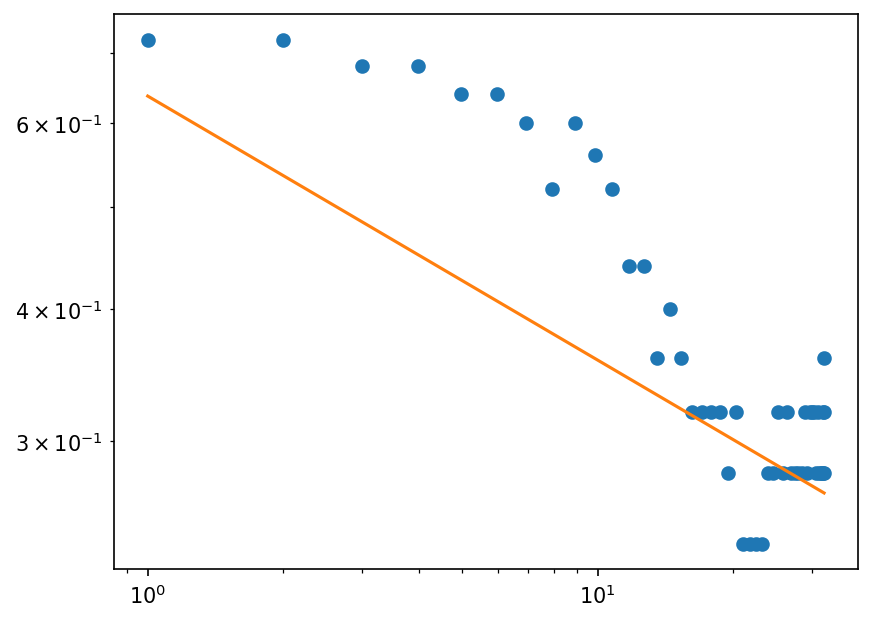

In [65]:
N = 1
for i in range(N):
    s_i, _ = psi.sample_measurements()
    if i == 0:
        s = [s_i]
    else:
        s.append(s_i)
s = np.array(s)
s = 2*s - 1
s = s.reshape(-1, psi.L)
y = [spatial_avg_2pt(s, d, periodic=True) for d in range(1, 51)]
x = np.arange(1, 51)
x_chord = np.sin(np.pi * x / psi.L) * psi.L / np.pi
plt.loglog(x_chord, y, 'o')
plt.plot(x_chord, 2/np.pi * (x_chord) ** (-0.25), label=r'$d^{-1/4}$')